In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/data/processed/retail_sales_features.csv", parse_dates=["date"])
df = df.sort_values("date")

In [3]:
print(df.shape)
print(df["date"].min(), df["date"].max())
df.head()

(4495000, 19)
2019-01-29 00:00:00 2023-12-31 00:00:00


,date,store_id,item_id,sales,price,promo,weekday,month,year,day,dayofweek,weekofyear,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2019-01-29,store_1,item_1,46,21.30,0,1,1,2019,29,1,5,44.0,47.0,46.0,41.0,41.571429,41.428571,5.028490
3444968,2019-01-29,store_44,item_24,56,13.61,0,1,1,2019,29,1,5,48.0,55.0,48.0,47.0,45.571429,46.928571,7.114706
460288,2019-01-29,store_14,item_15,34,58.96,1,1,1,2019,29,1,5,17.0,18.0,19.0,24.0,19.285714,19.785714,3.251373
3446766,2019-01-29,store_44,item_25,50,71.53,0,1,1,2019,29,1,5,42.0,47.0,45.0,45.0,44.285714,42.428571,8.635475
3448564,2019-01-29,store_44,item_26,50,26.68,0,1,1,2019,29,1,5,46.0,51.0,45.0,40.0,43.000000,40.500000,6.480741


In [4]:
split_date = df["date"].quantile(0.8)

train = df[df["date"] < split_date]
test = df[df["date"] >= split_date]

In [5]:
print("Train:", train.shape)
print("Test:", test.shape)

Train: (3595000, 19)
Test: (900000, 19)


In [6]:
# Definimos variables
features = [col for col in df.columns if col not in ["date", "sales"]]

X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

In [7]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (3595000, 17)
y_train: (3595000,)


In [8]:
y_pred_baseline = test["lag_7"]

In [9]:
# Función evaluación
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [10]:
# Convertir a tipo categórico (MEJOR opción)
X_train["store_id"] = X_train["store_id"].astype("category")
X_train["item_id"] = X_train["item_id"].astype("category")

X_test["store_id"] = X_test["store_id"].astype("category")
X_test["item_id"] = X_test["item_id"].astype("category")

/var/folders/pz/j5008jt17nn61fm1_0r8cx3m0000gn/T/ipykernel_74672/4259231828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["store_id"] = X_train["store_id"].astype("category")
/var/folders/pz/j5008jt17nn61fm1_0r8cx3m0000gn/T/ipykernel_74672/4259231828.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["item_id"] = X_train["item_id"].astype("category")
/var/folders/pz/j5008jt17nn61fm1_0r8cx3m0000gn/T/ipykernel_74672/4259231828.py:5: SettingWithCopyWarning: 
A value is trying to be set o

In [11]:
# Modelo LightGBM
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032878 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1711
[LightGBM] [Info] Number of data points in the train set: 3595000, number of used features: 17
[LightGBM] [Info] Start training from score 28.542253


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
# Predicción
y_pred = model.predict(X_test)

In [15]:
test["predictions"] = y_pred

test.to_csv("/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/outputs/predictions.csv", index=False)

/var/folders/pz/j5008jt17nn61fm1_0r8cx3m0000gn/T/ipykernel_74672/3518966093.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["predictions"] = y_pred


In [16]:
# Evaluación Modelo
mae, rmse = evaluate(y_test, y_pred)

print("Modelo MAE:", mae)
print("Modelo RMSE:", rmse)

Modelo MAE: 2.5842017795525094
Modelo RMSE: 3.244152635224019


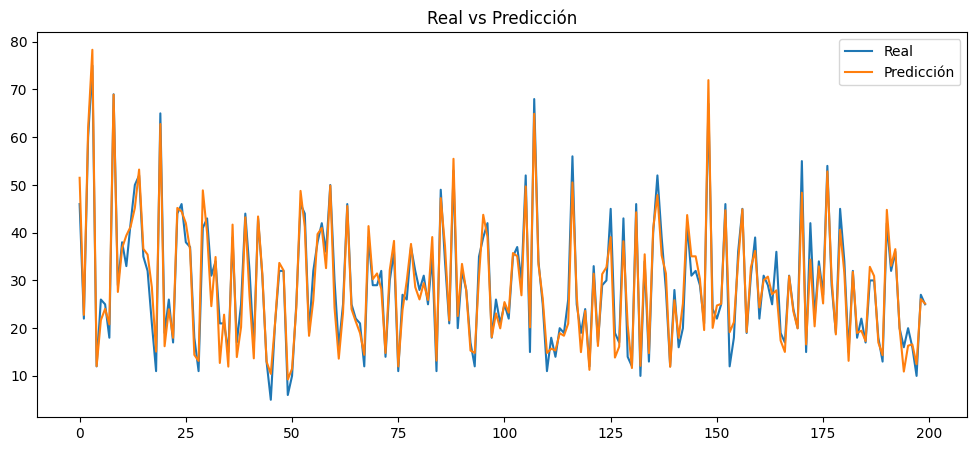

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Real")
plt.plot(y_pred[:200], label="Predicción")
plt.legend()
plt.title("Real vs Predicción")
plt.show()

In [18]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)

,feature,importance
1,item_id,2279
9,weekofyear,2237
11,lag_7,1885
4,weekday,1776
15,rolling_mean_14,1556
12,lag_14,1528
3,promo,781
10,lag_1,710
0,store_id,638
13,lag_28,599


In [19]:
# Guardamos resultados
import joblib

joblib.dump(model, "/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/models/model.pkl")

['/Users/marcelocallao/Desktop/Proyectos GitHub/Sistema de Predicción de Demanda y Optimización de Inventario en Retail/models/model.pkl']

# El modelo de gradient boosting logró capturar patrones temporales complejos, superando significativamente al baseline basado en lags